In [60]:
#import libraries

import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeClassifier,plot_tree
from sklearn.metrics import f1_score, classification_report, confusion_matrix,accuracy_score

In [11]:
#load dataset

df = pd.read_csv("shop_smart_ecommerce.csv")

X = df.drop(columns=["Revenue"])
y = df["Revenue"].astype(int)

In [13]:
y.dtype

dtype('int64')

In [14]:
df.head()

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,1,1,1,1,Returning_Visitor,False,False
1,0,0.0,0,0.0,2,64.000000,0.00,0.10,0.0,0.0,Feb,2,2,1,2,Returning_Visitor,False,False
2,0,0.0,0,0.0,1,0.000000,0.20,0.20,0.0,0.0,Feb,4,1,9,3,Returning_Visitor,False,False
3,0,0.0,0,0.0,2,2.666667,0.05,0.14,0.0,0.0,Feb,3,2,2,4,Returning_Visitor,False,False
4,0,0.0,0,0.0,10,627.500000,0.02,0.05,0.0,0.0,Feb,3,3,1,4,Returning_Visitor,True,False


In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12330 entries, 0 to 12329
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Administrative           12330 non-null  int64  
 1   Administrative_Duration  12330 non-null  float64
 2   Informational            12330 non-null  int64  
 3   Informational_Duration   12330 non-null  float64
 4   ProductRelated           12330 non-null  int64  
 5   ProductRelated_Duration  12330 non-null  float64
 6   BounceRates              12330 non-null  float64
 7   ExitRates                12330 non-null  float64
 8   PageValues               12330 non-null  float64
 9   SpecialDay               12330 non-null  float64
 10  Month                    12330 non-null  object 
 11  OperatingSystems         12330 non-null  int64  
 12  Browser                  12330 non-null  int64  
 13  Region                   12330 non-null  int64  
 14  TrafficType           

In [22]:
num_features = X.select_dtypes(include=["int64", "float64"]).columns
cat_features = X.select_dtypes(include=["object", "bool"]).columns


In [30]:
X_train, X_test, y_train, y_test = train_test_split(
    X,y,test_size=0.2,random_state=42,stratify=y)

In [31]:
# Preprocessng Pipeline
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_features) #handle unknown the encoder safely ignonres unseen cat
    ]
)

In [32]:
dt = DecisionTreeClassifier(
    max_depth=6,              # prevents deep overfitting
    min_samples_leaf=30,      # smooths decision boundaries
    class_weight="balanced",  # handles imbalance
    random_state=42
)

In [39]:
pipe = Pipeline(
    steps=[
        ("preprocess", preprocessor),
        ("model", dt)
    ]
)

In [40]:
pipe.fit(X_train, y_train)

,steps,"[('preprocess', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [41]:
y_pred = pipe.predict(X_test)

print("F1 score:", f1_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))

F1 score: 0.6278381046396841

Classification Report:
               precision    recall  f1-score   support

           0       0.97      0.85      0.90      2084
           1       0.50      0.83      0.63       382

    accuracy                           0.85      2466
   macro avg       0.73      0.84      0.77      2466
weighted avg       0.89      0.85      0.86      2466


Confusion Matrix:
 [[1771  313]
 [  64  318]]


In [57]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    "model__max_depth": [4, 6, 8],
    "model__min_samples_leaf": [20, 30, 50]
}

grid = GridSearchCV(
    pipe,
    param_grid,
    scoring="f1",
    cv=5,
    n_jobs=-1   #faster completion specifies the number of cpu core used by GSCV for parallel processing
)

grid.fit(X_train, y_train)

print("Best F1:", grid.best_score_)
print("Best params:", grid.best_params_)

Best F1: 0.6343735129725652
Best accuracy: 0.6343735129725652
Best params: {'model__max_depth': 4, 'model__min_samples_leaf': 50}


Test Accuracy: 0.8438767234387672


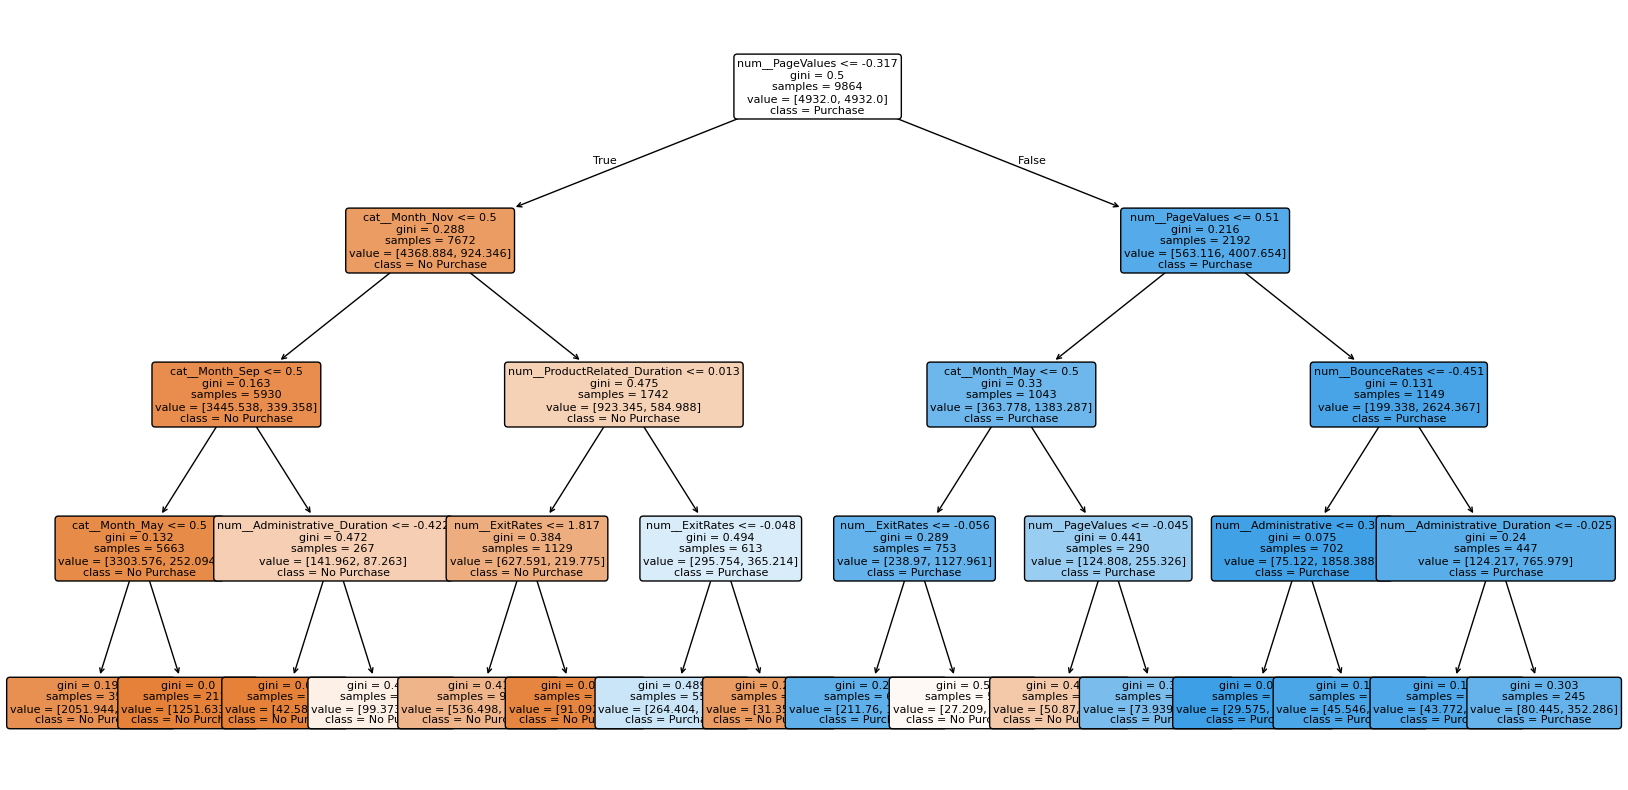

In [61]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

# Get best pipeline from GridSearchCV
best_pipe = grid.best_estimator_

#Predictions on test data
y_pred = best_pipe.predict(X_test)

# Calculate accuracy
accuracy = accuracy_score(y_test, y_pred)

print("Test Accuracy:", accuracy)